# **Licenciatura em Ciências da Computação**

### Aprendizagem Computacional 25/26

# Ensembles, Feature Importance, Permutation Importance, Undersampling/Oversampling (SMOTE)

## Imports
The code is kept simple and explicit so it is easy to explain live in class.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, make_moons, make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, average_precision_score, precision_recall_curve,
    roc_curve, balanced_accuracy_score
)
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

## Utility functions
Small helper functions make the notebook easier to read.

In [ ]:
def plot_confusion_matrix_simple(cm, labels=("Negative", "Positive"), title="Confusion Matrix"):
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(labels); ax.set_yticklabels(labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.show()


def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, zz, alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", s=35)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

# 1) Ensemble intuition (Random Forest): single tree vs random forest

A single decision tree is often a **high-variance model**:
small changes in the data can lead to very different trees.

A random forest reduces variance by:
- training many trees
- using bootstrap samples
- combining their predictions

**max_depth=None** means:

the tree is allowed to grow without any explicit depth limit

But that doesn’t mean infinite growth—it stops when one of these conditions happens:

*   a node becomes pure (all samples same class)

*   there are too few samples to split (controlled by min_samples_split, min_samples_leaf)

*   no split improves the criterion (e.g., Gini / entropy)

Shallow Tree (max_depth=2)
  Train accuracy: 0.895
  Test accuracy:  0.800

Deep Tree (max_depth=None)
  Train accuracy: 1.000
  Test accuracy:  0.778

Random Forest (500 trees)
  Train accuracy: 1.000
  Test accuracy:  0.844



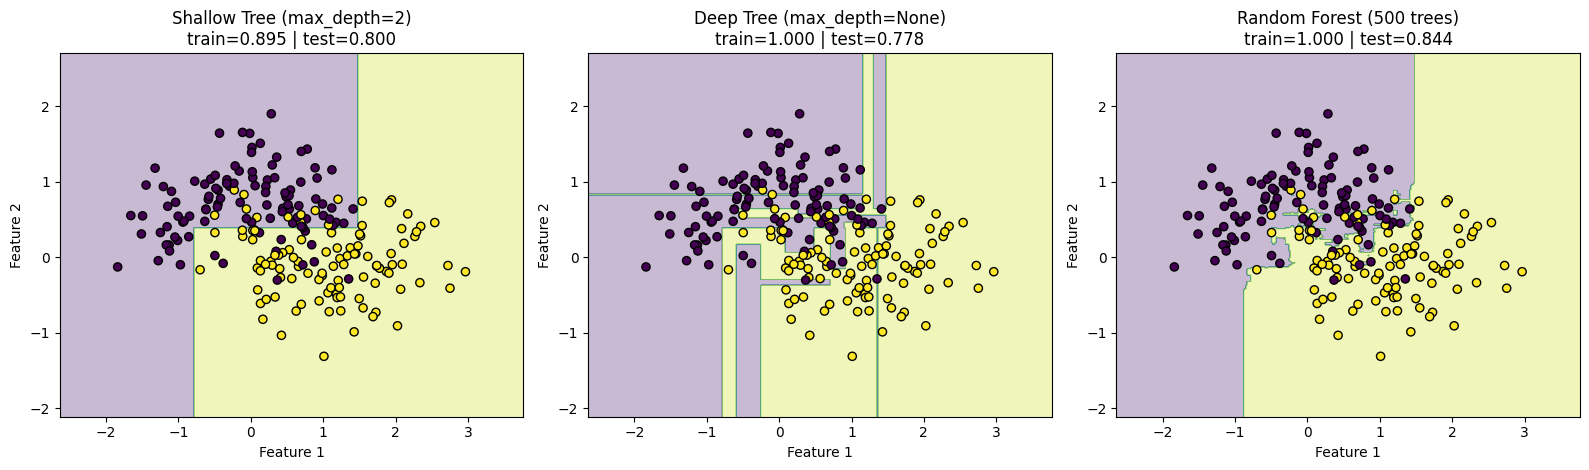

In [ ]:
# This takes a long time to run!!

# # dataset
# X, y = make_moons(n_samples=300, noise=0.35, random_state=42)

# # split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y,
#     test_size=0.30,
#     random_state=42,
#     stratify=y
# )

# # models
# models = {
#     "Shallow Tree (max_depth=2)": DecisionTreeClassifier(max_depth=2, random_state=42),
#     "Deep Tree (max_depth=None)": DecisionTreeClassifier(max_depth=None, random_state=42),
#     "Random Forest (500 trees)": RandomForestClassifier(
#     n_estimators=500,
#     max_depth=None,
#     max_features="sqrt",
#     random_state=42
# ),
# }

# # fit + scores
# results = {}

# for name, model in models.items():
#     model.fit(X_train, y_train)

#     train_acc = accuracy_score(y_train, model.predict(X_train))
#     test_acc = accuracy_score(y_test, model.predict(X_test))

#     results[name] = (train_acc, test_acc)

# # print scores
# for name, (train_acc, test_acc) in results.items():
#     print(f"{name}")
#     print(f"  Train accuracy: {train_acc:.3f}")
#     print(f"  Test accuracy:  {test_acc:.3f}")
#     print()

# # plot
# fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# for ax, (name, model) in zip(axes, models.items()):
#     train_acc, test_acc = results[name]
#     title = f"{name}\ntrain={train_acc:.3f} | test={test_acc:.3f}"
#     plot_decision_boundary(model, X_train, y_train, ax, title)

# plt.tight_layout()
# plt.show()

### Interpretation
- a **single tree** can create a very irregular boundary
- a **random forest** often produces a more stable decision rule

# 2) Real dataset

We will use the Breast Cancer Wisconsin dataset again so the workflow stays consistent with Aula 4.

In [ ]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset shape:", X.shape)
print("Class distribution:")
print(y.value_counts().sort_index())
X.head()

Dataset shape: (569, 30)
Class distribution:
target
0    212
1    357
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Train / test split

The test set remains untouched until the final evaluation.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)

Train shape: (455, 30)
Test shape:  (114, 30)


# 3) Random Forest hyperparameter search

We tune a Random Forest using cross-validation on the training set only.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid={
        "n_estimators": [100, 200, 400],  # Number of trees in the forest
        "max_depth": [None, 3, 5, 10], # Maximum depth of the tree (None means unlimited)
        "min_samples_leaf": [1, 2, 4], # Minimum number of samples required to be at a leaf node
        "max_features": ["sqrt", 0.5], # how many features each tree is allowed to consider at each split
                          #sqrt -> max_features = √(n_features)
    },
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best parameters:")
print(rf_grid.best_params_)
print("Best CV accuracy:", round(rf_grid.best_score_, 4))


Best parameters:
{'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 400}
Best CV accuracy: 0.9648


# 4) Feature Importance

Random Forest provides `feature_importances_`.

This is impurity-based importance (a.k.a. Gini importance)

Measures how much each feature reduces impurity across all trees

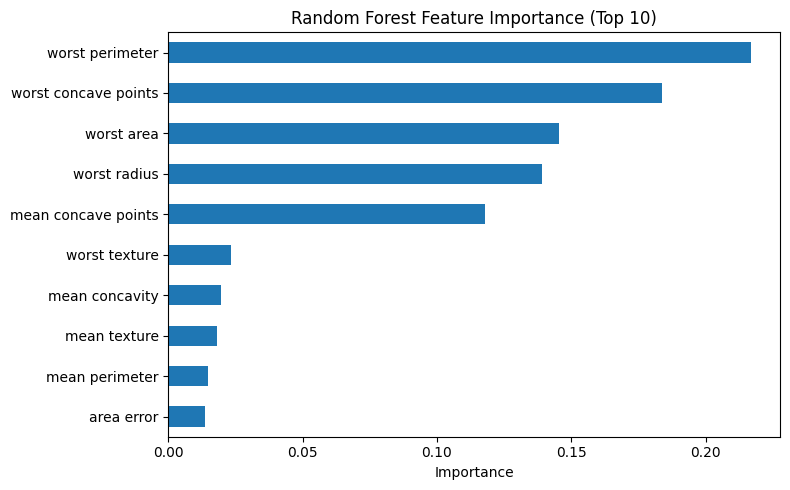

In [ ]:
best_rf = rf_grid.best_estimator_

rf_importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
rf_importances.head(10).sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance (Top 10)")
plt.tight_layout()
plt.show()

### Important note
Tree-based feature importance is useful, but it can be affected by:
- correlated features
- the way splits are chosen
- bias toward some variables

That is why we also look at **permutation importance**.

# 5) Permutation Importance

Permutation importance answers a practical question:

> If we destroy the information in one feature, how much worse does the model become?

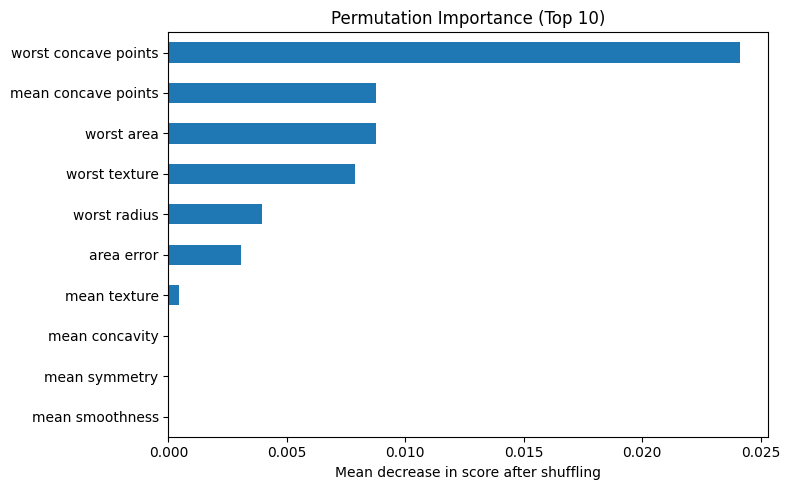

In [ ]:
perm = permutation_importance(
    best_rf, X_test, y_test, n_repeats=20, random_state=42, n_jobs=-1
)

perm_importances = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
perm_importances.head(10).sort_values().plot(kind="barh")
plt.xlabel("Mean decrease in score after shuffling")
plt.title("Permutation Importance (Top 10)")
plt.tight_layout()
plt.show()

# 6) Final evaluation on the untouched test set

Now we evaluate the tuned Random Forest on the test set.

In [ ]:
test_proba = best_rf.predict_proba(X_test)[:, 1]
test_pred = best_rf.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, test_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test, test_proba), 4))
print("Average Precision:", round(average_precision_score(y_test, test_proba), 4))
print()
print(classification_report(y_test, test_pred, target_names=["malignant", "benign"]))

Accuracy: 0.9561
ROC AUC: 0.9917
Average Precision: 0.9952

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



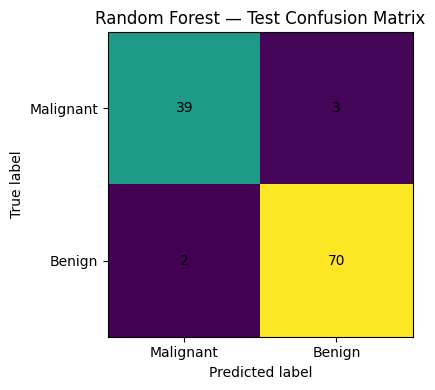

In [ ]:
cm = confusion_matrix(y_test, test_pred)
plot_confusion_matrix_simple(cm, labels=("Malignant", "Benign"), title="Random Forest — Test Confusion Matrix")

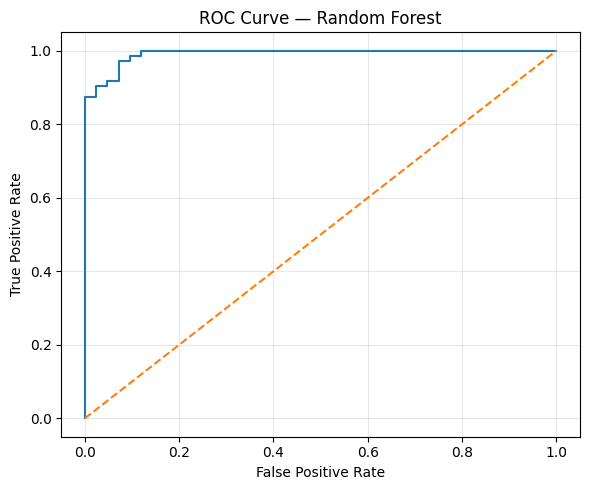

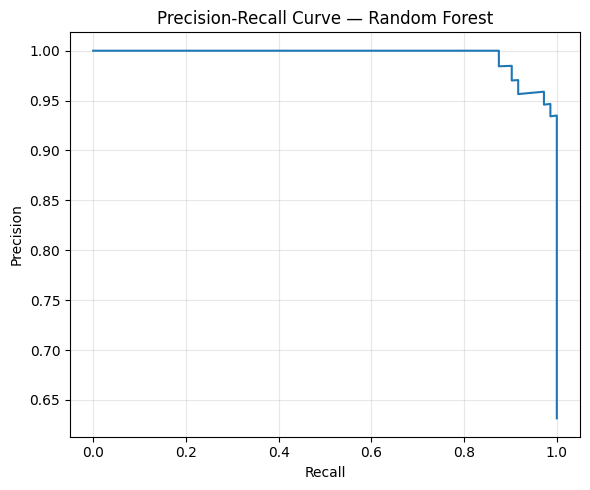

In [ ]:
fpr, tpr, _ = roc_curve(y_test, test_proba)
precision, recall, _ = precision_recall_curve(y_test, test_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Random Forest")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

## 7) Ensembling with RF, SVM, and Logistic Regression





In [ ]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Base estimators
clf1 = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        C=1.0,
        random_state=42,
        solver="liblinear"
    ))
])

clf2 = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    max_features=0.5,
    min_samples_leaf=1,
    random_state=42
)

clf3 = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(
        C=3.0,
        kernel="rbf",
        gamma="scale",    ## gamma = 1 / (n_features * X.var()); adapts to data scale (good default)
        probability=True,
        random_state=42
    ))
])

# Soft voting ensemble
eclf1 = VotingClassifier(
    estimators=[("lr", clf1), ("rf", clf2), ("svc", clf3)],
    voting="soft",
    weights=[1, 2, 1]
)

eclf1.fit(X_train, y_train)

ensemble_pred = eclf1.predict(X_test)
ensemble_proba = eclf1.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, ensemble_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test, ensemble_proba), 4))
print("Average Precision:", round(average_precision_score(y_test, ensemble_proba), 4))
print()
print(classification_report(y_test, ensemble_pred, target_names=["malignant", "benign"]))

Accuracy: 0.9825
ROC AUC: 0.996
Average Precision: 0.9976

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



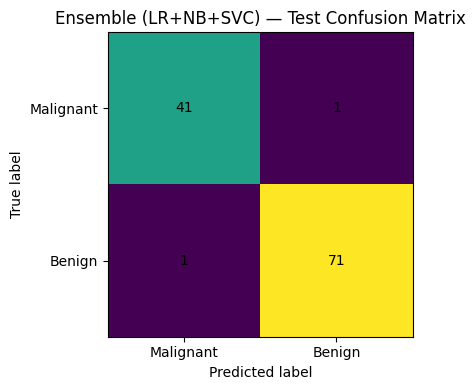

In [ ]:
cm_ensemble = confusion_matrix(y_test, ensemble_pred)
plot_confusion_matrix_simple(cm_ensemble, labels=("Malignant", "Benign"), title="Ensemble (LR+NB+SVC) — Test Confusion Matrix")

## Soft Voting (intuition)

Each model outputs probabilities:

p₁ = [0.2, 0.8]  
p₂ = [0.6, 0.4]  
p₃ = [0.3, 0.7]  

Average → [0.37, 0.63] → class 1

---

**With weights**

weights = [1, 1, 2]

weighted avg = (1·p₁ + 1·p₂ + 2·p₃) / 4  

→ p₁, p₂, p₃ are the probabilities from each model  
→ higher weight = more influence

---
---


# 8) Class imbalance




Accuracy can be misleading when one class is much more common than the other.

To demonstrate imbalance handling clearly, we will create a separate synthetic imbalanced dataset.

In [ ]:
X_imb, y_imb = make_classification(
    n_samples=1200,
    n_features=10,
    n_informative=4,
    n_redundant=2,
    n_clusters_per_class=1,
    weights=[0.90, 0.10],
    class_sep=1.0,
    flip_y=0.01,
    random_state=42
)

X_imb = pd.DataFrame(X_imb, columns=[f"feature_{i}" for i in range(X_imb.shape[1])])
y_imb = pd.Series(y_imb, name="target")

print("Class distribution:")
print(y_imb.value_counts(normalize=True).sort_index())

Class distribution:
target
0    0.894167
1    0.105833
Name: proportion, dtype: float64


In [ ]:
X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imb, y_imb, test_size=0.20, stratify=y_imb, random_state=42
)

## Baseline model without rebalancing

In [ ]:
baseline_rf = RandomForestClassifier(random_state=42)
baseline_rf.fit(X_train_imb, y_train_imb)

baseline_pred = baseline_rf.predict(X_test_imb)
baseline_proba = baseline_rf.predict_proba(X_test_imb)[:, 1]

print("Accuracy:", round(accuracy_score(y_test_imb, baseline_pred), 4))
print("Balanced accuracy:", round(balanced_accuracy_score(y_test_imb, baseline_pred), 4))
print("Average Precision:", round(average_precision_score(y_test_imb, baseline_proba), 4))
print()
print(classification_report(y_test_imb, baseline_pred, target_names=["majority", "minority"]))

Accuracy: 0.9875
Balanced accuracy: 0.94
Average Precision: 0.9938

              precision    recall  f1-score   support

    majority       0.99      1.00      0.99       215
    minority       1.00      0.88      0.94        25

    accuracy                           0.99       240
   macro avg       0.99      0.94      0.96       240
weighted avg       0.99      0.99      0.99       240



### Why this matters
With imbalanced data, a model can achieve high accuracy simply by focusing too much on the majority class.

So we should also inspect:
- recall for the minority class
- balanced accuracy
- precision-recall behaviour

# 9) Oversampling with SMOTE

SMOTE creates synthetic minority examples using the training data.

For each minority sample:

*   Pick one of its nearest minority neighbors
*   Interpolate between them

Important:
**SMOTE must be applied only inside the training process**, never before the train/test split.

In [ ]:
smote_pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

smote_pipeline.fit(X_train_imb, y_train_imb)

smote_pred = smote_pipeline.predict(X_test_imb)
smote_proba = smote_pipeline.predict_proba(X_test_imb)[:, 1]

print("Accuracy:", round(accuracy_score(y_test_imb, smote_pred), 4))
print("Balanced accuracy:", round(balanced_accuracy_score(y_test_imb, smote_pred), 4))
print("Average Precision:", round(average_precision_score(y_test_imb, smote_proba), 4))
print()
print(classification_report(y_test_imb, smote_pred, target_names=["majority", "minority"]))

Accuracy: 0.9917
Balanced accuracy: 0.9953
Average Precision: 0.9921

              precision    recall  f1-score   support

    majority       1.00      0.99      1.00       215
    minority       0.93      1.00      0.96        25

    accuracy                           0.99       240
   macro avg       0.96      1.00      0.98       240
weighted avg       0.99      0.99      0.99       240



# 10) Undersampling

Undersampling reduces the number of majority-class examples.

This can help the model focus more on the minority class, but it also throws away data.

In [ ]:
under_pipeline = ImbPipeline([
    ("under", RandomUnderSampler(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

under_pipeline.fit(X_train_imb, y_train_imb)

under_pred = under_pipeline.predict(X_test_imb)
under_proba = under_pipeline.predict_proba(X_test_imb)[:, 1]

print("Accuracy:", round(accuracy_score(y_test_imb, under_pred), 4))
print("Balanced accuracy:", round(balanced_accuracy_score(y_test_imb, under_pred), 4))
print("Average Precision:", round(average_precision_score(y_test_imb, under_proba), 4))
print()
print(classification_report(y_test_imb, under_pred, target_names=["majority", "minority"]))

Accuracy: 0.9042
Balanced accuracy: 0.8935
Average Precision: 0.9184

              precision    recall  f1-score   support

    majority       0.98      0.91      0.94       215
    minority       0.52      0.88      0.66        25

    accuracy                           0.90       240
   macro avg       0.75      0.89      0.80       240
weighted avg       0.94      0.90      0.91       240



## Compare baseline vs SMOTE vs undersampling

## Balanced Accuracy vs Average Precision

**Balanced Accuracy**
$$
\frac{\text{Recall}_{majority} + \text{Recall}_{minority}}{2}
$$
- Uses predictions (fixed threshold)  
- Handles imbalance by treating classes equally  

**Average Precision (AP)**
- Area under Precision–Recall curve  
- Uses probabilities (all thresholds)  
- Focuses on ranking positives  

**Summary**
- Balanced accuracy → performance per class  
- Average precision → quality of ranking (more informative for imbalance)

In [ ]:
comparison = pd.DataFrame([
    {
        "method": "Baseline RF",
        "accuracy": accuracy_score(y_test_imb, baseline_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test_imb, baseline_pred),
        "average_precision": average_precision_score(y_test_imb, baseline_proba),
    },
    {
        "method": "RF + SMOTE",
        "accuracy": accuracy_score(y_test_imb, smote_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test_imb, smote_pred),
        "average_precision": average_precision_score(y_test_imb, smote_proba),
    },
    {
        "method": "RF + Undersampling",
        "accuracy": accuracy_score(y_test_imb, under_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test_imb, under_pred),
        "average_precision": average_precision_score(y_test_imb, under_proba),
    },
])

comparison

,method,accuracy,balanced_accuracy,average_precision
0,Baseline RF,0.987500,0.940000,0.993770
1,RF + SMOTE,0.991667,0.995349,0.992104
2,RF + Undersampling,0.904167,0.893488,0.918416


#Scikit-Learn Models

Differente models available on Scikit-Learn depending on use case: [Link](https://scikit-learn.org/stable/machine_learning_map.html)